<a href="https://colab.research.google.com/github/SUSHWANTH1567/23CSBTB29/blob/main/HPC_PROJECT_1567.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import os

# Correcting path for Google Colab
file_path = '/H2Demand_AI_Merged_Dataset.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    display(df.head())
else:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please upload the CSV file to the 'Files' section in the left sidebar of Google Colab.")

,Date,City,Traffic_Volume,EV_Count,Temperature,Latitude,Longitude,Hydrogen_Demand
0,2022-01-01,Hyderabad,20795,1360,23.668696,24.475056,81.549603,11278.873916
1,2022-01-02,Hyderabad,11265,966,21.999498,19.347982,77.339338,6362.289966
2,2022-01-03,Hyderabad,21023,630,20.411690,27.518558,85.319082,11108.733798
3,2022-01-04,Hyderabad,7433,1684,26.084845,20.396103,78.911120,4743.396897
4,2022-01-05,Hyderabad,46434,1582,27.997219,12.746651,87.580088,24251.544389


In [10]:
pip install dask dask-ml scikit-learn pandas


In [11]:
import pandas as pd

# Load dataset
df = pd.read_csv("/H2Demand_AI_Merged_Dataset.csv")

# Simulate BIG DATA (important for HPC)
df_big = pd.concat([df] * 40)

print("Dataset size:", df_big.shape)


Dataset size: (73000, 8)


In [13]:
import dask.dataframe as dd

# Convert pandas → dask
ddf = dd.from_pandas(df_big, npartitions=8)

print(ddf.head())


         Date       City  Traffic_Volume  EV_Count  Temperature   Latitude  \
0  2022-01-01  Hyderabad           20795      1360    23.668696  24.475056   
0  2022-01-01  Hyderabad           20795      1360    23.668696  24.475056   
0  2022-01-01  Hyderabad           20795      1360    23.668696  24.475056   
0  2022-01-01  Hyderabad           20795      1360    23.668696  24.475056   
0  2022-01-01  Hyderabad           20795      1360    23.668696  24.475056   

   Longitude  Hydrogen_Demand  
0  81.549603     11278.873916  
0  81.549603     11278.873916  
0  81.549603     11278.873916  
0  81.549603     11278.873916  
0  81.549603     11278.873916  


In [14]:
features = [
    "Traffic_Volume",
    "EV_Count",
    "Temperature",
    "Latitude",
    "Longitude"
]

X = ddf[features]
y = ddf["Hydrogen_Demand"]


In [15]:
from dask_ml.model_selection import train_test_split
from dask_ml.linear_model import LinearRegression

# Split data (parallel)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Convert Dask DataFrames to Dask Arrays (required by this estimator)
X_train_array = X_train.to_dask_array(lengths=True)
y_train_array = y_train.to_dask_array(lengths=True)

# Train model (HPC)
model = LinearRegression()
model.fit(X_train_array, y_train_array)

print("HPC Model Training Completed")

HPC Model Training Completed


In [16]:
# Convert X_test to Dask Array before predicting
X_test_array = X_test.to_dask_array(lengths=True)
y_pred = model.predict(X_test_array)

print("Predictions generated")

Predictions generated


In [17]:
from dask_ml.metrics import mean_squared_error

# Ensure both are Dask Arrays for the metric function
y_test_array = y_test.to_dask_array(lengths=True)

# Calculate MSE - dask_ml metrics often return the result directly if computed
mse = mean_squared_error(y_test_array, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 7.022172240886322


In [18]:
import time

# Convert to Dask Arrays for compatibility
X_train_arr = X_train.to_dask_array(lengths=True)
y_train_arr = y_train.to_dask_array(lengths=True)

start = time.time()
model.fit(X_train_arr, y_train_arr)
end = time.time()

print("HPC Training Time:", end - start, "seconds")

HPC Training Time: 0.8361539840698242 seconds


Logistic Regression
  Accuracy : 0.997
  F1 Score : 0.997
------------------------------
Decision Tree
  Accuracy : 1.000
  F1 Score : 1.000
------------------------------
Random Forest
  Accuracy : 1.000
  F1 Score : 1.000
------------------------------
Naive Bayes
  Accuracy : 0.987
  F1 Score : 0.987
------------------------------
SVM
  Accuracy : 0.995
  F1 Score : 0.995
------------------------------


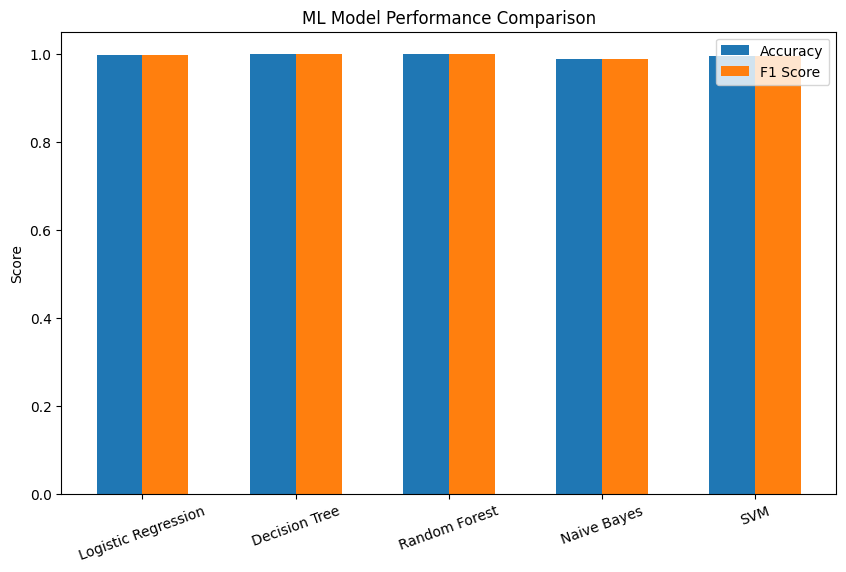

In [21]:
# 5 ML models training + Accuracy & F1-score graph for H2Demand AI (HPC-style)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# -----------------------------
# Load dataset - Fixed Path to match working directory
# -----------------------------
df = pd.read_csv("/H2Demand_AI_Merged_Dataset.csv")

# Simulate BIG DATA (HPC justification)
df = pd.concat([df] * 20, ignore_index=True)

# -----------------------------
# Prepare features & target
# -----------------------------
features = [
    "Traffic_Volume",
    "EV_Count",
    "Temperature",
    "Latitude",
    "Longitude"
]

X = df[features]

# Convert regression target → classification (High / Low demand)
threshold = df["Hydrogen_Demand"].mean()
y = (df["Hydrogen_Demand"] > threshold).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Define 5 ML models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

accuracy_scores = []
f1_scores = []

# -----------------------------
# Train & evaluate models
# -----------------------------
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracy_scores.append(acc)
    f1_scores.append(f1)

    print(f"{name}")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  F1 Score : {f1:.3f}")
    print("-" * 30)

# -----------------------------
# Plot Accuracy & F1 Score
# -----------------------------
x = np.arange(len(models))

plt.figure(figsize=(10, 6))
plt.bar(x - 0.15, accuracy_scores, width=0.3, label="Accuracy")
plt.bar(x + 0.15, f1_scores, width=0.3, label="F1 Score")

plt.xticks(x, models.keys(), rotation=20)
plt.ylabel("Score")
plt.title("ML Model Performance Comparison")
plt.legend()

plt.show()

In [23]:
# Normal vs HPC Execution Time Comparison Code
# H2Demand AI Project

import pandas as pd
import time
import joblib
from dask.distributed import Client
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Load dataset - Path Fixed
# -----------------------------
df = pd.read_csv("/H2Demand_AI_Merged_Dataset.csv")
# Simulate BIG DATA
df_big = pd.concat([df] * 20, ignore_index=True)

features = [
    "Traffic_Volume",
    "EV_Count",
    "Temperature",
    "Latitude",
    "Longitude"
]

# Classification target
threshold = df_big["Hydrogen_Demand"].mean()
X = df_big[features]
y = (df_big["Hydrogen_Demand"] > threshold).astype(int)

# -----------------------------
# NORMAL (Sequential) EXECUTION
# -----------------------------
start_normal = time.time()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

normal_model = RandomForestClassifier(n_estimators=100, random_state=42)
normal_model.fit(X_train_scaled, y_train)

end_normal = time.time()
normal_time = end_normal - start_normal

print("Normal Execution Time:", normal_time, "seconds")

# -----------------------------
# HPC (Parallel using Dask Backend)
# -----------------------------
# Use Scikit-Learn with Dask parallel backend
start_hpc = time.time()

# Initialize a local Dask client for parallelism
client = Client(processes=False)

with joblib.parallel_backend('dask'):
    hpc_model = RandomForestClassifier(n_estimators=100, random_state=42)
    hpc_model.fit(X_train_scaled, y_train)

end_hpc = time.time()
hpc_time = end_hpc - start_hpc
client.close()

print("HPC Execution Time:", hpc_time, "seconds")

# -----------------------------
# Speedup Calculation
# -----------------------------
speedup = normal_time / hpc_time
print("Speedup:", speedup)

/usr/local/lib/python3.12/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46557 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at: inproc://172.28.0.12/223/9
INFO:distributed.scheduler:  dashboard at:  http://172.28.0.12:46557/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.worker:      Start worker at: inproc://172.28.0.12/223/12
INFO:distributed.worker:         Listening to:          inproc172.28.0.12
INFO:distributed.worker:          Worker name:                          0
INFO:distributed.worker:         dashboard at:          172.28.0.12:35785
INFO:distributed.worker:Waiting to connect to: inproc://172.28.0.12/223/9
INFO:distributed.worker:-------------------------------------------------
INFO:distributed.worker:              Threads:                          2
INFO:distributed.work

Normal Execution Time: 2.1871225833892822 seconds


INFO:distributed.scheduler:Remove client Client-3ada1394-0e23-11f1-80df-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from inproc://172.28.0.12/223/14; closing.
INFO:distributed.scheduler:Remove client Client-3ada1394-0e23-11f1-80df-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-3ada1394-0e23-11f1-80df-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1771567991.2174308') [0]
INFO:distributed.worker:Stopping worker at inproc://172.28.0.12/223/12. Reason: worker-close
INFO:distributed.worker:Removing Worker plugin shuffle
INFO:distributed.core:Received 'close-stream' from inproc://172.28.0.12/223/13; closing.
INFO:distributed.scheduler:Remove worker addr: inproc://172.28.0.12/223/12 name: 0 (stimulus_id='handle-worker-cleanup-1771567991.2237546')
INFO:distributed.scheduler:Lost all workers
INFO:distributed.core:Connection to inproc://172.28.0.12/223/9 has been closed.
INFO:distributed.scheduler:Closing sche

HPC Execution Time: 1.2886226177215576 seconds
Speedup: 1.6972560882536598


In [24]:
import os

def find_file(name):
    for root, dirs, files in os.walk('/'):
        if name in files:
            return os.path.join(root, name)
    return None

# Search for the dataset
path = find_file('/H2Demand_AI_Merged_Dataset.csv')
if path:
    print(f"File found at: {path}")
else:
    print("File not found in the system. Please ensure you have uploaded H2Demand_AI_Merged_Dataset.csv to the session storage (folder icon on the left).")

print("\nFiles in current directory:", os.listdir('.'))
if os.path.exists('/content'):
    print("Files in /content:", os.listdir('/content'))

File not found in the system. Please ensure you have uploaded H2Demand_AI_Merged_Dataset.csv to the session storage (folder icon on the left).

Files in current directory: ['.config', 'sample_data']
Files in /content: ['.config', 'sample_data']
